# 2D-1D wavelet deconvolution of a dirty ALMA spectral cube

Goes from a dirty-beam-convolved, noisy ALMA-like cube to a "clean" cube
using the `Deconvolver2D1D` sparse-recovery algorithm in `src/deconvolver.py`
-- a deconvolution counterpart of the `Denoiser2D1D` denoiser from
[`Denoiser2D1D-improved`](../../Denoiser2D1D-improved), built on the same
kind of 2D (spatial) x 1D (spectral) wavelet dictionary, but solving
`Y = H(X) + N` (dirty beam convolution) instead of `Y = X + N` (pure noise).
See the repo `README.md` for the full derivation of what has to change
between the two, including two non-obvious pitfalls encountered while
building this: the interferometer's missing zero-spacing flux, and how
noise-level calibration has to route through the beam.

This notebook:
1. builds a toy, spatially-varying (non-stationary) spectral cube: a single
   rotating ring that splits into two spatially separated blobs in most
   velocity channels due to its kinematics,
2. builds a toy but structurally real ALMA-like dirty beam from a mock
   antenna layout and simulated Earth-rotation synthesis,
3. convolves + adds noise to get a dirty cube, and shows the dirty beam and
   dirty central channel,
4. runs the 2D-1D wavelet deconvolution and compares true / dirty /
   recovered channel maps.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt

from toy_cube import rotating_ring_cube, count_blobs
from psf import mock_alma_dirty_beam, beam_fwhm_pixels
from deconvolver import Deconvolver2D1D, convolve_cube

np.random.seed(0)
plt.rcParams['figure.facecolor'] = 'white'

## 1. Toy non-stationary rotating-ring cube

The line-of-sight velocity at each point on the ring is `v_los = v_max *
sin(theta)`, i.e. it depends on spatial position (`theta`, the azimuthal
angle around the ring) -- the spectral line profile is *not* the same shape
everywhere in the field of view. At a fixed channel velocity `v0`, only the
two points on the ring where `v_los(theta) = v0` are bright, so a single,
spatially connected source shows up as two separated blobs in most
channels, merging into one only at the rotation curve's extremes (top/bottom
of the ring).

cube shape (nz, ny, nx) = (41, 80, 80)
true total flux = 874.6
peak brightness  = 0.9934


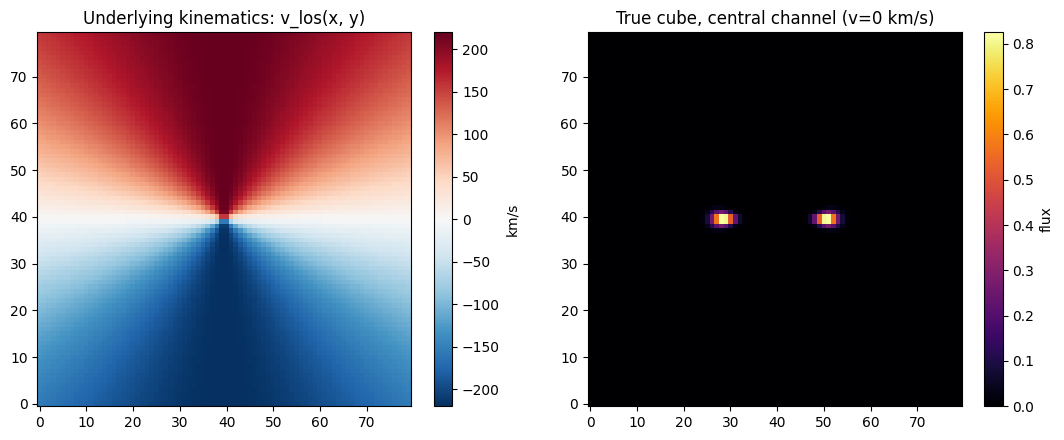

In [3]:
cube, velocities, v_los = rotating_ring_cube(
    nz=41, ny=80, nx=80, v_max=220.0, line_sigma=18.0,
    ring_radius=11.0, ring_sigma=1.6, peak_flux=1.0,
)
nz, ny, nx = cube.shape
center_channel = nz // 2
print(f'cube shape (nz, ny, nx) = {cube.shape}')
print(f'true total flux = {cube.sum():.4g}')
print(f'peak brightness  = {cube.max():.4g}')

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axs[0].imshow(v_los, origin='lower', cmap='RdBu_r')
axs[0].set_title('Underlying kinematics: v_los(x, y)')
plt.colorbar(im0, ax=axs[0], label='km/s', fraction=0.046)

im1 = axs[1].imshow(cube[center_channel], origin='lower', cmap='inferno')
axs[1].set_title(f'True cube, central channel (v={velocities[center_channel]:.0f} km/s)')
plt.colorbar(im1, ax=axs[1], label='flux', fraction=0.046)
plt.tight_layout()
plt.show()

In [4]:
# Quick scan: how many spatially separated blobs does the true source show
# in each channel? (0.3x that channel's own peak, dependency-free
# connected-components count from toy_cube.count_blobs)
print(f"{'chan':>4} {'v (km/s)':>9} {'peak':>7} {'n_blobs':>7}")
for k in range(0, nz, 4):
    peak = cube[k].max()
    n_blobs, _ = count_blobs(cube[k], 0.3 * peak) if peak > 1e-6 else (0, None)
    print(f'{k:4d} {velocities[k]:9.0f} {peak:7.3f} {n_blobs:7d}')

chan  v (km/s)    peak n_blobs
   0      -286   0.001       1
   4      -229   0.841       1
   8      -172   0.968       2
  12      -114   0.973       2
  16       -57   0.934       2
  20         0   0.825       2
  24        57   0.934       2
  28       114   0.973       2
  32       172   0.968       2
  36       229   0.841       1
  40       286   0.001       1


## 2. Toy ALMA-like dirty beam

Built from an actual (mock) antenna layout and simulated Earth-rotation
aperture synthesis, not hand-drawn: random antenna positions -> baseline
vectors for every antenna pair at several array rotation angles -> grid the
resulting (u, v) points -> the dirty beam is the inverse FFT of that
sampling function. Because baselines always occur as (i, j)/(j, i) +/- pairs,
the sampling function -- and hence the beam -- is exactly centro-symmetric,
which is also why the beam's convolution operator can be reused as its own
adjoint in the deconvolution's gradient step (see `deconvolver.py`).

In [6]:
beam, sampling, (ant_x, ant_y), (u, v) = mock_alma_dirty_beam(
    n_ant=14, max_radius=100.0,
    hour_angles_deg=np.linspace(-40, 40, 5),
    grid_size=81, natural_weighting=False, seed=2,
)
print(f'beam shape = {beam.shape}, peak = {beam.max():.3f}')
print(f'beam.sum() = {beam.sum():.3e}  <-- ~0: no zero-length baseline is ever measured,')
print('               so the dirty beam has essentially zero DC (total-flux) response.')
print(f'uv sampling fill fraction = {(sampling > 0).mean():.3f}')
print(f'main-lobe FWHM ~ {beam_fwhm_pixels(beam):.1f} pixels')
print(f'beam is centro-symmetric: {np.allclose(beam, beam[::-1, ::-1])}')

beam shape = (81, 81), peak = 1.000
beam.sum() = 9.992e-16  <-- ~0: no zero-length baseline is ever measured,
               so the dirty beam has essentially zero DC (total-flux) response.
uv sampling fill fraction = 0.122
main-lobe FWHM ~ 2.0 pixels
beam is centro-symmetric: True


## 3. Dirty cube = true cube (*) dirty beam + noise

Convolve every channel of the true cube with the same dirty beam (FFT-based,
`deconvolver.convolve_cube`), then add Gaussian noise at a fixed peak SNR.

In [8]:
dirty_clean = convolve_cube(cube, beam)  # PSF-convolved, no noise yet

peak_snr = 8.0
sigma_noise = dirty_clean.max() / peak_snr
rng = np.random.default_rng(42)
dirty_cube = dirty_clean + rng.normal(0.0, sigma_noise, size=dirty_clean.shape)

print(f'peak SNR = {peak_snr}, noise sigma = {sigma_noise:.4g}')
print(f'dirty cube min/max = {dirty_cube.min():.3g} / {dirty_cube.max():.3g}')
print(f'(true cube min/max was {cube.min():.3g} / {cube.max():.3g} -- note the dirty')
print(' map goes negative and overshoots the true peak: classic dirty-beam sidelobe bowls.')

peak SNR = 8.0, noise sigma = 0.3413
dirty cube min/max = -1.68 / 3.31
(true cube min/max was 4.11e-302 / 0.993 -- note the dirty
 map goes negative and overshoots the true peak: classic dirty-beam sidelobe bowls.


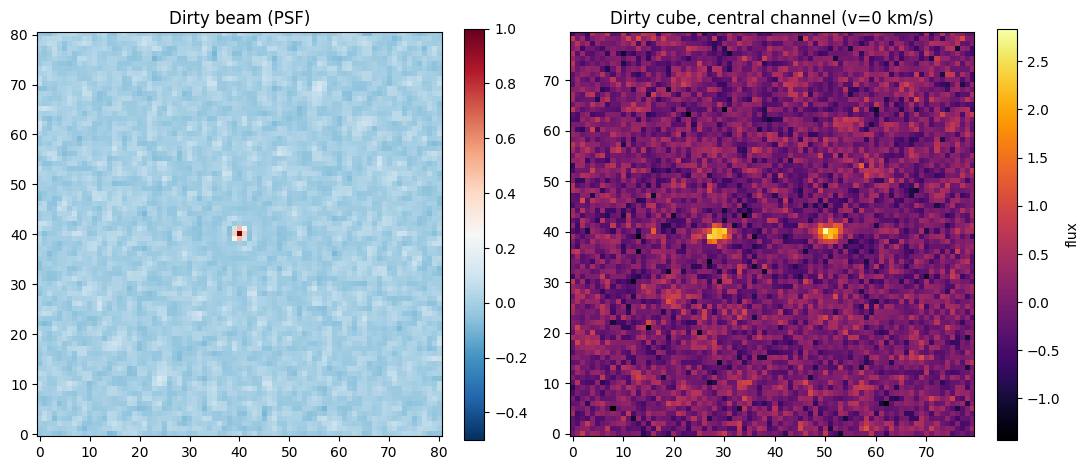

In [9]:
# --- Required figure: dirty PSF and the dirty central channel, one figure, subplots ---
fig, axs = plt.subplots(1, 2, figsize=(11, 4.8))

im0 = axs[0].imshow(beam, origin='lower', cmap='RdBu_r', vmin=-0.5, vmax=1.0)
axs[0].set_title('Dirty beam (PSF)')
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(dirty_cube[center_channel], origin='lower', cmap='inferno')
axs[1].set_title(f'Dirty cube, central channel (v={velocities[center_channel]:.0f} km/s)')
plt.colorbar(im1, ax=axs[1], fraction=0.046, label='flux')

plt.tight_layout()
plt.show()

## 4. 2D-1D wavelet deconvolution

`Deconvolver2D1D` runs FISTA (accelerated ISTA): at each iteration, a
gradient step w.r.t. the data-fidelity term `||dirty - H(x)||^2` is taken,
then the result is projected onto the sparse set by soft-thresholding its
2D-1D wavelet coefficients, then positivity is enforced. The detection
threshold decays from `k_start` to `k_end` (in units of sigma) over the
iterations. See `README.md` / `deconvolver.py` docstrings for the full
derivation from the original denoiser.

In [11]:
deconvolver = Deconvolver2D1D(
    num_scales_2d=4, num_scales_1d=3,
    threshold_type='soft', positivity=True, verbose=True,
)
model, history = deconvolver.deconvolve(
    dirty_cube, beam, sigma_noise,
    n_iter=70, k_start=6.0, k_end=2.5, fista=True,
)

[Deconvolver2D1D] 4 spatial scales x 3 spectral scales, 70 FISTA iterations (soft thresholding)
[Deconvolver2D1D] Lipschitz constant L=235, step size mu=0.004255
[Deconvolver2D1D] per-subband noise levels estimated (finest subband sigma=0.00173)
  iter    1/70  k_sigma=6.00  residual_std=0.3821  flux=103.1
  iter    8/70  k_sigma=5.64  residual_std=0.3643  flux=329.3
  iter   15/70  k_sigma=5.29  residual_std=0.3594  flux=389.1
  iter   22/70  k_sigma=4.93  residual_std=0.3587  flux=395.4
  iter   29/70  k_sigma=4.58  residual_std=0.3576  flux=405.4
  iter   36/70  k_sigma=4.22  residual_std=0.3563  flux=416.6
  iter   43/70  k_sigma=3.87  residual_std=0.3552  flux=426.9
  iter   50/70  k_sigma=3.51  residual_std=0.3541  flux=438
  iter   57/70  k_sigma=3.16  residual_std=0.3531  flux=449.2
  iter   64/70  k_sigma=2.80  residual_std=0.3521  flux=461.7
  iter   70/70  k_sigma=2.50  residual_std=0.3512  flux=474.1


In [12]:
rmse_dirty = np.sqrt(np.mean((dirty_clean - cube) ** 2))
rmse_model = np.sqrt(np.mean((model - cube) ** 2))
print(f'true flux            = {cube.sum():.4g}')
print(f'dirty flux           = {dirty_cube.sum():.4g}')
print(f'recovered flux       = {model.sum():.4g}  '
      f'({100*model.sum()/cube.sum():.0f}% of true -- see the zero-spacing-flux note in README.md)')
print(f'RMSE(dirty, true)    = {rmse_dirty:.4g}')
print(f'RMSE(recovered, true)= {rmse_model:.4g}  ({rmse_dirty/rmse_model:.1f}x lower)')

true flux            = 874.6
dirty flux           = 438.3
recovered flux       = 474.1  (54% of true -- see the zero-spacing-flux note in README.md)
RMSE(dirty, true)    = 0.1615
RMSE(recovered, true)= 0.02022  (8.0x lower)


## 5. Recovery: true vs. dirty vs. recovered

First the central channel, then the channel that best shows the
kinematic splitting into two blobs.

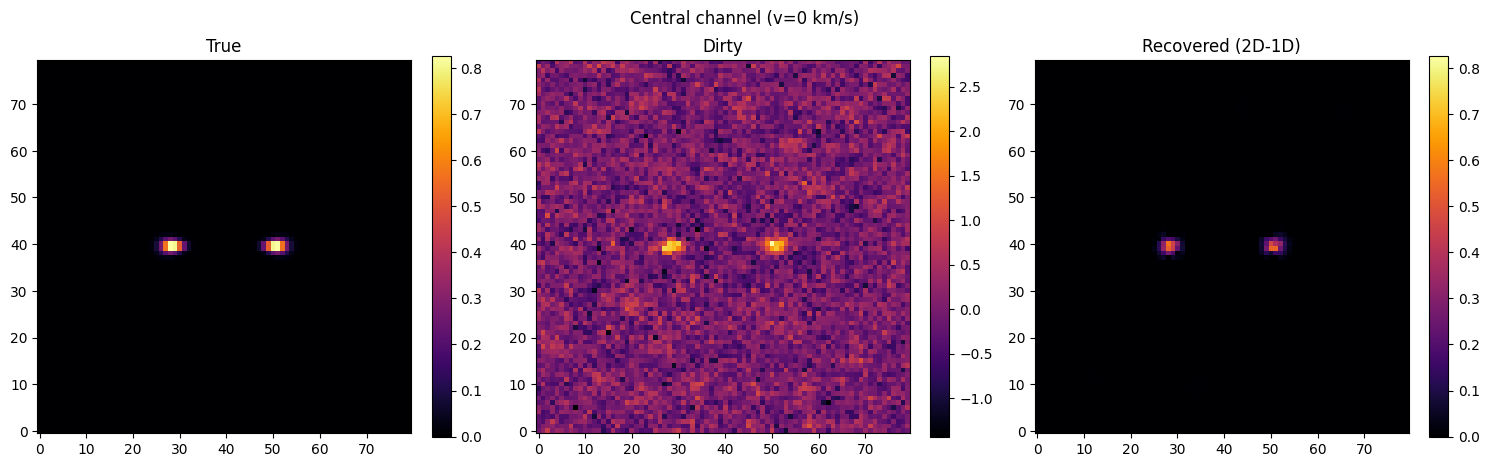

In [14]:
def compare_panels(k, title):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
    vmax = max(cube[k].max(), model[k].max(), 1e-6)
    for ax, img, name, cmap, vmin in [
        (axs[0], cube[k], 'True', 'inferno', 0),
        (axs[1], dirty_cube[k], 'Dirty', 'inferno', None),
        (axs[2], model[k], 'Recovered (2D-1D)', 'inferno', 0),
    ]:
        im = ax.imshow(img, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax if vmin is not None else None)
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

compare_panels(center_channel, f'Central channel (v={velocities[center_channel]:.0f} km/s)')

channel 7 (v=-186 km/s): n_blobs true=2, dirty(4-sigma)=4, recovered=2


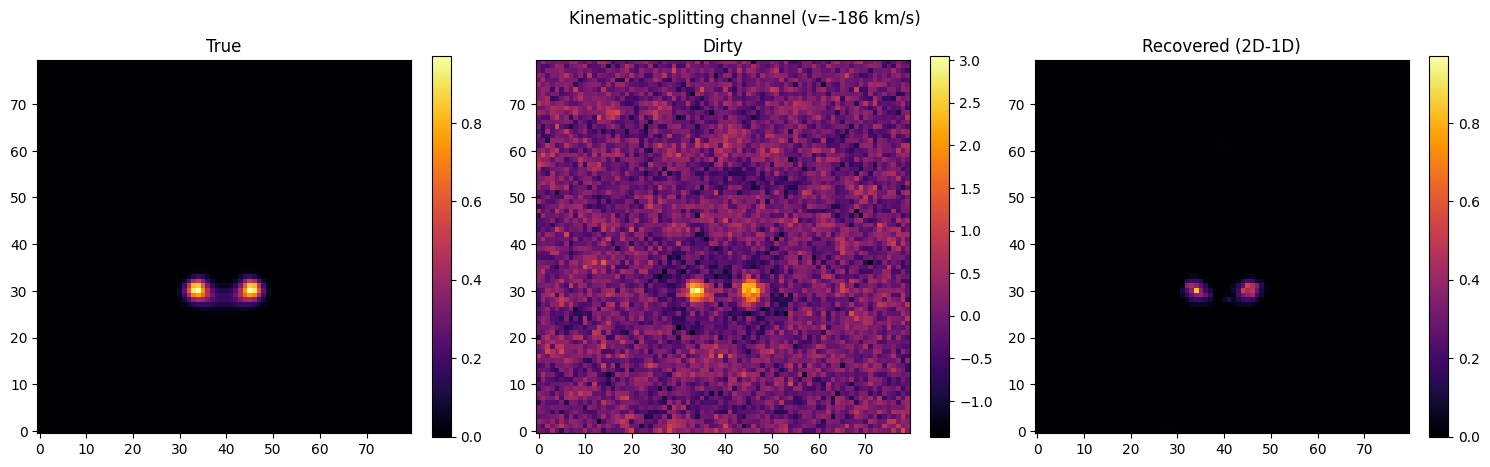

In [15]:
# Find the channel with the widest true blob separation for the clearest
# demonstration of recovering the kinematic splitting.
best_k, best_n = None, 0
for k in range(nz):
    peak = cube[k].max()
    if peak < 0.3 * cube.max():
        continue
    n_blobs, _ = count_blobs(cube[k], 0.3 * peak)
    if n_blobs >= 2:
        best_k = k
        break
split_k = best_k if best_k is not None else center_channel

n_true, _ = count_blobs(cube[split_k], 0.3 * cube[split_k].max())
n_dirty, _ = count_blobs(np.clip(dirty_cube[split_k], 0, None), 4 * sigma_noise)
n_model, _ = count_blobs(model[split_k], 0.3 * model[split_k].max() if model[split_k].max() > 0 else 1e9)
print(f'channel {split_k} (v={velocities[split_k]:.0f} km/s): '
      f'n_blobs true={n_true}, dirty(4-sigma)={n_dirty}, recovered={n_model}')

compare_panels(split_k, f'Kinematic-splitting channel (v={velocities[split_k]:.0f} km/s)')

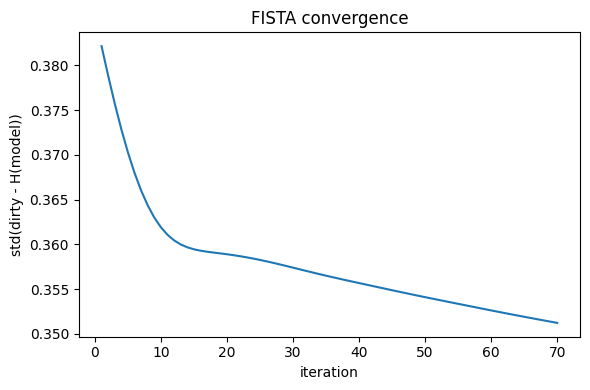

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(history['residual_std']) + 1), history['residual_std'])
plt.xlabel('iteration')
plt.ylabel('std(dirty - H(model))')
plt.title('FISTA convergence')
plt.tight_layout()
plt.show()

## Takeaways

- The dirty beam's sidelobes (not a clean Gaussian PSF -- real interferometric
  dirty beams never are) visibly corrupt the central channel with negative
  bowls and spurious ripples; the 2D-1D wavelet deconvolution removes most of
  that structure and brings the RMSE to the true cube down substantially.
- The kinematic splitting (one ring, two blobs in most channels) is preserved
  through deconvolution -- the 2D-1D dictionary models extended/structured
  emission natively, unlike CLEAN's delta-function components, which is the
  practical payoff of using it here.
- Recovered total flux undershoots the true flux. This is expected, not a
  bug: the dirty beam has ~zero response at the zero-spacing (DC) mode
  (`beam.sum() ~ 0`), so that flux is fundamentally unconstrained by the
  data for *any* deconvolution method, CLEAN included. See `README.md` for
  how `Deconvolver2D1D` handles that null space (zeroing the coarsest
  wavelet sub-band instead of leaving it free, which otherwise makes the
  FISTA iteration diverge).